<link rel="stylesheet" href="notebook_theme.css">

In [1]:
import os
from openai import OpenAI

client = OpenAI(
    base_url="https://api.studio.nebius.ai/v1/",
    api_key=os.environ["NEBIUS_API_KEY"]
)

resp = client.chat.completions.create(
    model="meta-llama/Meta-Llama-3.1-8B-Instruct",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Explain AI agents in one sentence."}
    ],
    temperature=0.7,
    max_tokens=100
)

print(resp.choices[0].message.content)
print(resp.usage)

An AI agent is a software program that uses artificial intelligence to perform tasks, make decisions, and interact with its environment, whether it's a user, a system, or a physical space.
CompletionUsage(completion_tokens=39, prompt_tokens=29, total_tokens=68, completion_tokens_details=None, prompt_tokens_details=None)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Dummy data: y = 2x + 1
x = torch.randn(100, 1)
y = 2 * x + 1 + 0.1 * torch.randn(100, 1)

# Model
model = nn.Linear(1, 1)

# Loss
criterion = nn.MSELoss()

# Optimizer (SGD)
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Training loop
for epoch in range(100):
    optimizer.zero_grad()
    
    output = model(x)
    loss = criterion(output, y)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Learned parameters
print("Weight:", model.weight.item())
print("Bias:", model.bias.item())

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

# ----------------------------
# 1. Reproducibility
# ----------------------------
torch.manual_seed(42)

# ----------------------------
# 2. Generate synthetic data
# y = 2x + 1 + noise
# ----------------------------
x = torch.randn(100, 1)
noise = 0.1 * torch.randn(100, 1)
y = 2 * x + 1 + noise

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice will be used: {device}")
model.to(device)
x, y = x.to(device), y.to(device)

# ----------------------------
# 3. Define model
# ----------------------------
model = nn.Linear(1, 1)

# ----------------------------
# 4. Loss function
# ----------------------------
criterion = nn.MSELoss()

# ----------------------------
# 5. Optimizer (SGD)
# ----------------------------
optimizer = optim.SGD(model.parameters(), lr=0.1)

# ----------------------------
# 6. L1 Regularization strength
# ----------------------------
l1_lambda = 0.01

# ----------------------------
# 7. Training loop
# ----------------------------
num_epochs = 100

for epoch in range(num_epochs):
    # Reset gradients
    optimizer.zero_grad()

    # Forward pass
    output = model(x)

    # Base loss
    loss = criterion(output, y)

    # ----------------------------
    # L1 Regularization
    # ----------------------------
    l1_norm = sum(p.abs().sum() for p in model.parameters())
    loss = loss + l1_lambda * l1_norm

    # ----------------------------
    # Backward pass
    # ----------------------------
    loss.backward()

    # ----------------------------
    # Gradient clipping (numerical stability)
    # ----------------------------
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # Update parameters
    optimizer.step()

    # Logging
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")

# ----------------------------
# 8. Final parameters
# ----------------------------
print("\nLearned parameters:")
print(f"Weight: {model.weight.item():.4f}")
print(f"Bias:   {model.bias.item():.4f}")


Device will be used: cpu
Epoch 000 | Loss: 2.313537
Epoch 010 | Loss: 0.306920
Epoch 020 | Loss: 0.041521
Epoch 030 | Loss: 0.037858
Epoch 040 | Loss: 0.037804
Epoch 050 | Loss: 0.037803
Epoch 060 | Loss: 0.037803
Epoch 070 | Loss: 0.037803
Epoch 080 | Loss: 0.037803
Epoch 090 | Loss: 0.037803

Learned parameters:
Weight: 1.9963
Bias:   0.9989


Matplotlib is building the font cache; this may take a moment.


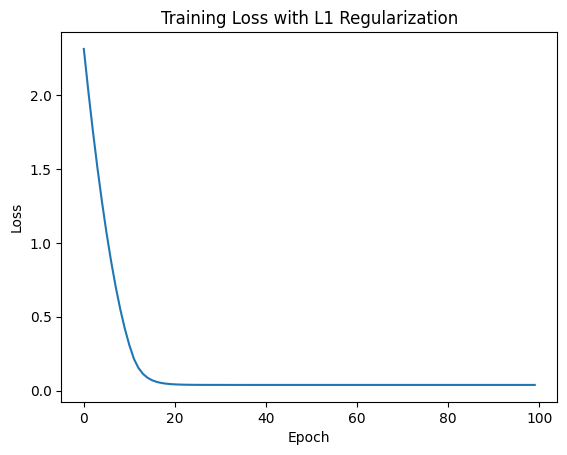

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ----------------------------
# DATA
# ----------------------------
x = torch.randn(100, 1)
y = 2 * x + 1 + 0.1 * torch.randn(100, 1)

# ----------------------------
# MODEL
# ----------------------------
model = nn.Linear(1, 1)

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

l1_lambda = 0.01

losses = []

# ----------------------------
# TRAINING
# ----------------------------
for epoch in range(100):
    optimizer.zero_grad()

    output = model(x)
    loss = criterion(output, y)

    # L1
    l1_norm = sum(p.abs().sum() for p in model.parameters())
    loss = loss + l1_lambda * l1_norm

    loss.backward()

    # stability
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()

    losses.append(loss.item())

# ----------------------------
# PLOT
# ----------------------------
plt.figure()
plt.plot(losses)
plt.title("Training Loss with L1 Regularization")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

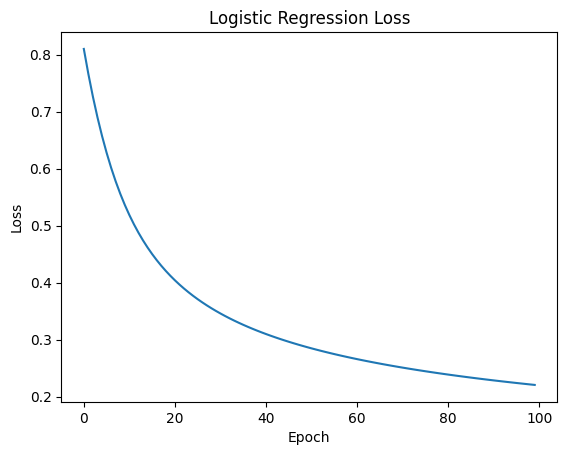

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

# ----------------------------
# DATA (classification)
# ----------------------------
N = 200
X = torch.randn(N, 2)

# Simple linear boundary
y = (X[:, 0] + X[:, 1] > 0).long()

# ----------------------------
# MODEL
# ----------------------------
model = nn.Linear(2, 2)  # 2 classes

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

losses = []

# ----------------------------
# TRAINING
# ----------------------------
for epoch in range(100):
    optimizer.zero_grad()

    logits = model(X)

    loss = criterion(logits, y)

    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()

    losses.append(loss.item())

# ----------------------------
# PLOT LOSS
# ----------------------------
plt.figure()
plt.plot(losses)
plt.title("Logistic Regression Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Check if MPS (Apple Silicon GPU) is available
import torch
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')
